# Task 3: Real-World Dataset Analysis Project

This notebook analyzes a reproducible synthetic customer-sales dataset. It needs no network access. A fixed random seed makes the 240 generated customers, planted missing values, duplicate, and high-spend outlier repeatable. The dataset is illustrative, not actual customer information.

## 1. Dataset Selection & Contextualization

### Business goal
Assess how acquisition channel and customer engagement relate to monthly spend, satisfaction, and churn. The analysis should highlight useful customer segments, data-quality concerns, and measurable hypotheses for retention and marketing experiments.

### Expected outcomes
Produce a cleaned analysis table, compare customer and commercial metrics across channels, visualize distributions and relationships, and translate the results into testable business recommendations. Since the records are synthetic, use the findings to demonstrate an analytical workflow rather than to make real budget decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
n_customers = 240

regions = rng.choice(['North', 'South', 'East', 'West'], size=n_customers, p=[0.27, 0.23, 0.25, 0.25])
channels = rng.choice(['Website', 'Referral', 'Social', 'Store', 'Email'], size=n_customers, p=[0.30, 0.20, 0.18, 0.17, 0.15])
age = rng.integers(18, 76, size=n_customers)
visits = np.maximum(0, rng.poisson(lam=6.5, size=n_customers) + np.isin(channels, ['Referral', 'Email']).astype(int))
channel_spend = pd.Series(channels).map({'Website': 8, 'Referral': 24, 'Social': -6, 'Store': 12, 'Email': 15}).to_numpy()
monthly_spend = 35 + visits * 21 + channel_spend + rng.normal(0, 38, size=n_customers)
monthly_spend = np.maximum(monthly_spend, 15)
satisfaction = np.clip(2.3 + visits * 0.22 + rng.normal(0, 0.65, size=n_customers), 1, 5)
channel_churn = pd.Series(channels).map({'Website': 0.01, 'Referral': -0.08, 'Social': 0.11, 'Store': 0.00, 'Email': -0.03}).to_numpy()
churn_probability = np.clip(0.13 + (4.0 - satisfaction) * 0.12 + (5 - visits) * 0.025 + channel_churn, 0.03, 0.75)
churned = np.where(rng.random(n_customers) < churn_probability, 'Yes', 'No')

df = pd.DataFrame({
    'Customer_ID': np.arange(10001, 10001 + n_customers),
    'Age': age,
    'Region': regions,
    'Acquisition_Channel': channels,
    'Monthly_Spend': monthly_spend.round(2),
    'Visits_Per_Month': visits,
    'Satisfaction_Score': satisfaction.round(1),
    'Churned': churned,
})

# Add documented data-quality issues so the cleaning workflow has real work to do.
df.loc[3, 'Monthly_Spend'] = np.nan
df.loc[17, 'Satisfaction_Score'] = np.nan
df.loc[28, 'Region'] = np.nan
df.loc[0, 'Monthly_Spend'] = 2500.00  # Deliberately planted high-spend outlier.
df = pd.concat([df, df.iloc[[5]]], ignore_index=True)  # One exact duplicate row.

print(f'Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns (includes one planted duplicate).')
print('Column names:', df.columns.tolist())
print('Data types:')
display(df.dtypes.to_frame('dtype'))
print('DataFrame info:')
df.info()
print('Preview:')
display(df.head())

Dataset dimensions: 241 rows x 8 columns (includes one planted duplicate).
Column names: ['Customer_ID', 'Age', 'Region', 'Acquisition_Channel', 'Monthly_Spend', 'Visits_Per_Month', 'Satisfaction_Score', 'Churned']
Data types:


,dtype
Customer_ID,int64
Age,int64
Region,str
Acquisition_Channel,str
Monthly_Spend,float64
Visits_Per_Month,int64
Satisfaction_Score,float64
Churned,str


DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          241 non-null    int64  
 1   Age                  241 non-null    int64  
 2   Region               240 non-null    str    
 3   Acquisition_Channel  241 non-null    str    
 4   Monthly_Spend        240 non-null    float64
 5   Visits_Per_Month     241 non-null    int64  
 6   Satisfaction_Score   240 non-null    float64
 7   Churned              241 non-null    str    
dtypes: float64(2), int64(3), str(3)
memory usage: 15.2 KB
Preview:


,Customer_ID,Age,Region,Acquisition_Channel,Monthly_Spend,Visits_Per_Month,Satisfaction_Score,Churned
0,10001,26,West,Store,2500.00,14,5.0,No
1,10002,41,South,Store,129.58,4,3.5,Yes
2,10003,66,West,Website,302.51,12,5.0,No
3,10004,30,East,Social,NaN,3,1.9,Yes
4,10005,73,North,Social,134.92,9,3.7,No


## 2. Dataset Exploration

Review numeric distributions and the table's completeness before cleaning. The source data contains deliberately inserted missing values, one exact duplicate, and one spend outlier; the checks below quantify them rather than silently assuming the data is clean.

In [6]:
print('Descriptive statistics:')
display(df.describe())
print('Missing values by column:')
display(df.isnull().sum().to_frame('Missing_Count'))
duplicate_count = int(df.duplicated().sum())
print(f'Duplicate records: {duplicate_count}')
print('Categorical overview:')
display(df[['Region', 'Acquisition_Channel', 'Churned']].describe())

Descriptive statistics:


,Customer_ID,Age,Monthly_Spend,Visits_Per_Month,Satisfaction_Score
count,241.000000,241.000000,240.000000,241.000000,240.000000
mean,10120.024896,46.871369,199.257750,6.817427,3.777500
std,69.672922,15.872541,162.987591,2.661427,0.813224
min,10001.000000,18.000000,26.440000,0.000000,1.400000
25%,10060.000000,35.000000,145.940000,5.000000,3.300000
50%,10120.000000,47.000000,192.120000,7.000000,3.800000
75%,10180.000000,60.000000,231.890000,8.000000,4.400000
max,10240.000000,75.000000,2500.000000,16.000000,5.000000


Missing values by column:


,Missing_Count
Customer_ID,0
Age,0
Region,1
Acquisition_Channel,0
Monthly_Spend,1
Visits_Per_Month,0
Satisfaction_Score,1
Churned,0


Duplicate records: 1
Categorical overview:


,Region,Acquisition_Channel,Churned
count,240,241,241
unique,4,5,2
top,North,Website,No
freq,66,76,202


## 3. Data Cleaning & Preprocessing

Remove exact duplicate rows, impute numeric gaps with column medians and categorical gaps with modes, and set categorical columns to Pandas' category dtype. Detect outliers with the 1.5 x IQR rule. Here, cap flagged values at the IQR bounds rather than dropping customers, preserving sample size while limiting the planted extreme value's influence. The outlier report records how many values were capped in each numeric field.

In [10]:
df_clean = df.drop_duplicates().copy()
print(f'Removed {len(df) - len(df_clean)} duplicate row(s).')

numeric_columns = ['Age', 'Monthly_Spend', 'Visits_Per_Month', 'Satisfaction_Score']
categorical_columns = ['Region', 'Acquisition_Channel', 'Churned']

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode().iloc[0])
    df_clean[column] = df_clean[column].astype('category')
df_clean['Customer_ID'] = pd.to_numeric(df_clean['Customer_ID'], downcast='integer')

outlier_rows = []
for column in numeric_columns:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)
    outlier_rows.append({
        'Feature': column,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outliers_Capped': int(outlier_mask.sum()),
    })
    df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)
    if column == 'Visits_Per_Month':
        df_clean[column] = df_clean[column].round().astype(int)

outlier_report = pd.DataFrame(outlier_rows).set_index('Feature')
print('IQR outlier detection and capping:')
display(outlier_report.round(2))
print('Remaining missing values:', int(df_clean.isnull().sum().sum()))
print('Remaining duplicate rows:', int(df_clean.duplicated().sum()))
print('Cleaned dimensions:', df_clean.shape)
display(df_clean.head())

Removed 1 duplicate row(s).
IQR outlier detection and capping:


,Lower_Bound,Upper_Bound,Outliers_Capped
Feature,,,
Age,-2.50,97.50,0
Monthly_Spend,17.02,360.81,3
Visits_Per_Month,0.50,12.50,9
Satisfaction_Score,1.65,6.05,1


Remaining missing values: 0
Remaining duplicate rows: 0
Cleaned dimensions: (240, 8)


,Customer_ID,Age,Region,Acquisition_Channel,Monthly_Spend,Visits_Per_Month,Satisfaction_Score,Churned
0,10001,26,West,Store,360.815,12,5.0,No
1,10002,41,South,Store,129.580,4,3.5,Yes
2,10003,66,West,Website,302.510,12,5.0,No
3,10004,30,East,Social,191.750,3,1.9,Yes
4,10005,73,North,Social,134.920,9,3.7,No


## 4. Exploratory Data Analysis (EDA)

Compare numeric features with a correlation matrix and summarize customer behavior by acquisition channel. The channel table reports customer counts, average monthly spend, churn rate, and satisfaction. The interpretation below is generated from the cleaned data, so skewness and relationships reflect the actual seeded sample rather than assumed values.

In [11]:
df_clean['Churn_Flag'] = df_clean['Churned'].map({'No': 0, 'Yes': 1}).astype(int)
correlation_columns = ['Age', 'Monthly_Spend', 'Visits_Per_Month', 'Satisfaction_Score', 'Churn_Flag']
correlation = df_clean[correlation_columns].corr()
channel_summary = df_clean.groupby('Acquisition_Channel', observed=False).agg(
    Customer_Count=('Customer_ID', 'count'),
    Average_Monthly_Spend=('Monthly_Spend', 'mean'),
    Churn_Rate=('Churn_Flag', 'mean'),
    Average_Satisfaction=('Satisfaction_Score', 'mean'),
).sort_values('Average_Monthly_Spend', ascending=False)

print('Numeric correlations (excluding identifier):')
display(correlation.round(2))
print('Customer metrics by acquisition channel:')
display(channel_summary.style.format({
    'Average_Monthly_Spend': '${:,.2f}',
    'Churn_Rate': '{:.1%}',
    'Average_Satisfaction': '{:.2f}',
}))

spend_skewness = df_clean['Monthly_Spend'].skew()
visit_spend_corr = df_clean['Visits_Per_Month'].corr(df_clean['Monthly_Spend'])
churn_satisfaction = df_clean.groupby('Churned', observed=False)['Satisfaction_Score'].mean()
skew_description = 'right-skewed' if spend_skewness > 0.5 else 'left-skewed' if spend_skewness < -0.5 else 'approximately symmetric'
churn_comparison = (
    f"Average satisfaction is {churn_satisfaction.get('Yes', float('nan')):.2f} for churned customers and "
    f"{churn_satisfaction.get('No', float('nan')):.2f} for retained customers."
)
display(Markdown(
    f'**Observed patterns:** Monthly spend is **{skew_description}** (skewness {spend_skewness:.2f}) after IQR capping. '
    f'The Pearson correlation between monthly visits and spend is **{visit_spend_corr:.2f}**. {churn_comparison} '
    'These are descriptive relationships in synthetic data; they do not demonstrate that one measure causes another.'
))

Numeric correlations (excluding identifier):


,Age,Monthly_Spend,Visits_Per_Month,Satisfaction_Score,Churn_Flag
Age,1.00,0.03,0.09,0.13,-0.07
Monthly_Spend,0.03,1.00,0.78,0.47,-0.30
Visits_Per_Month,0.09,0.78,1.00,0.65,-0.36
Satisfaction_Score,0.13,0.47,0.65,1.00,-0.32
Churn_Flag,-0.07,-0.30,-0.36,-0.32,1.00


Customer metrics by acquisition channel:


,Customer_Count,Average_Monthly_Spend,Churn_Rate,Average_Satisfaction
Acquisition_Channel,,,,
Referral,40,$226.33,10.0%,3.97
Email,35,$216.56,11.4%,3.91
Store,44,$183.95,15.9%,3.71
Website,76,$173.90,15.8%,3.68
Social,45,$171.39,26.7%,3.72


**Observed patterns:** Monthly spend is **approximately symmetric** (skewness 0.16) after IQR capping. The Pearson correlation between monthly visits and spend is **0.78**. Average satisfaction is 3.19 for churned customers and 3.89 for retained customers. These are descriptive relationships in synthetic data; they do not demonstrate that one measure causes another.

## 5. Data Visualizations

The five views below cover spend distribution, group spread and potential outliers, engagement/spend relationships, numeric correlations, and acquisition-channel comparison. Each plot includes a title, labeled axes, and an explicit `plt.show()` call.

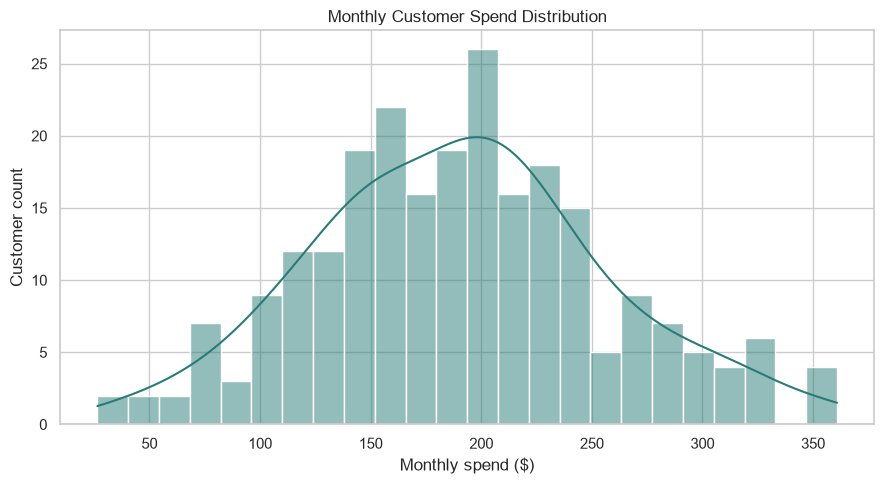

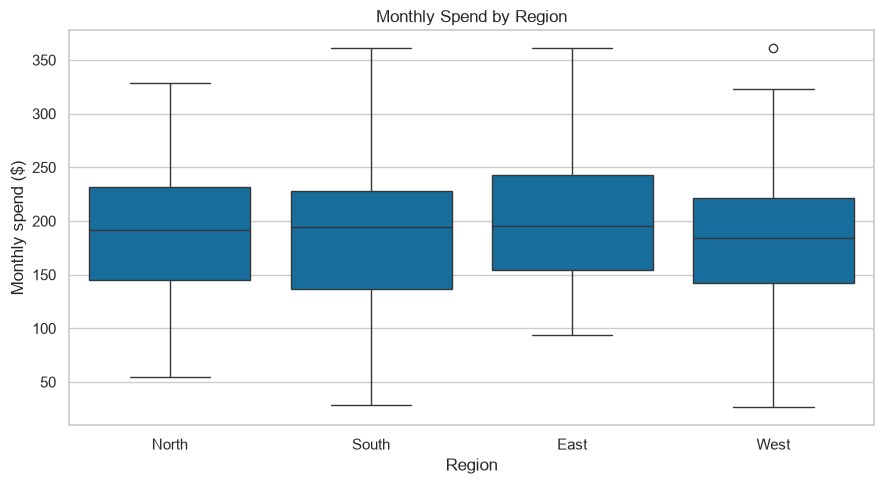

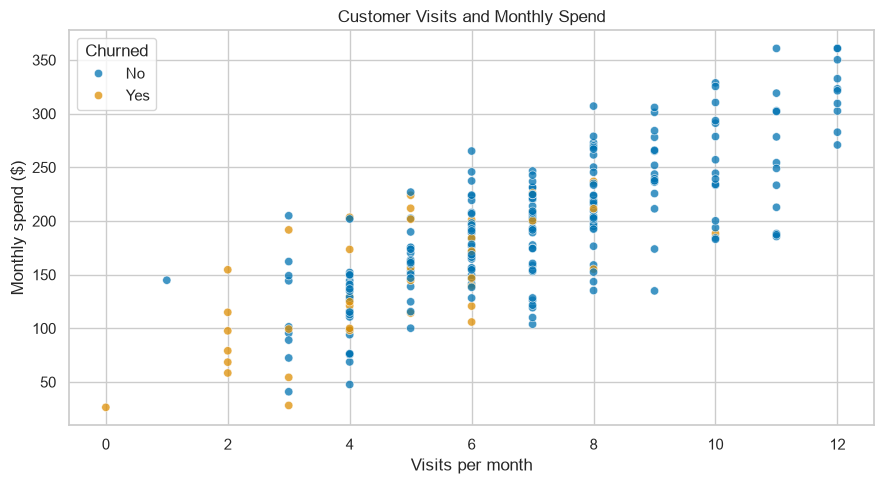

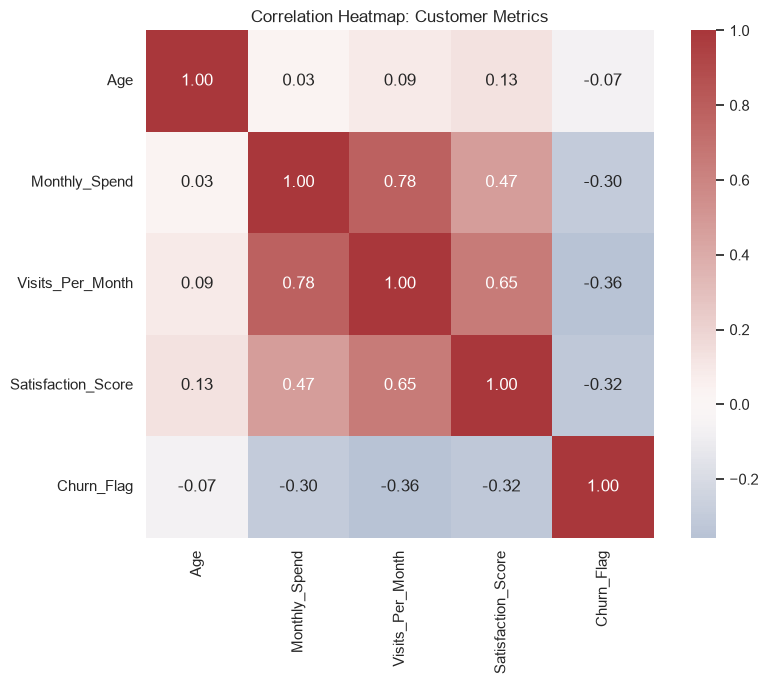

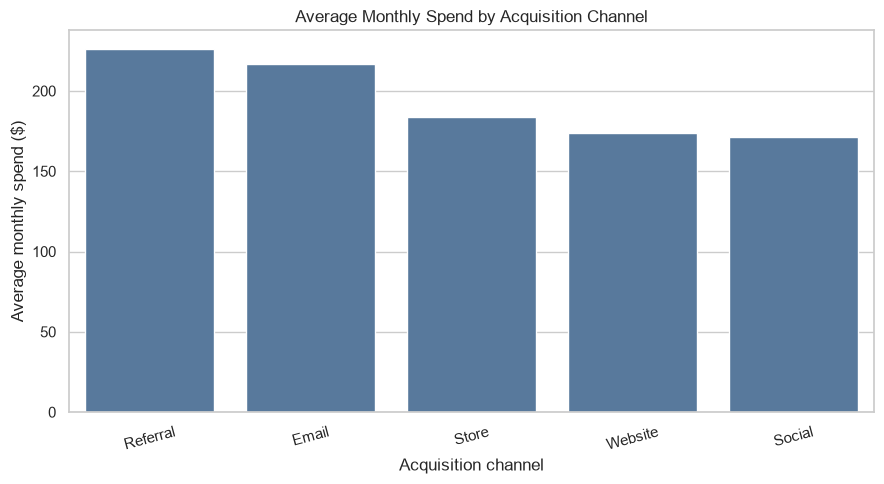

In [12]:
sns.set_theme(style='whitegrid', palette='colorblind')

# 1. Monthly spend distribution with histogram and KDE.
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_clean, x='Monthly_Spend', kde=True, bins=24, color='#287c78', ax=ax)
ax.set(title='Monthly Customer Spend Distribution', xlabel='Monthly spend ($)', ylabel='Customer count')
plt.tight_layout()
plt.show()

# 2. Spend spread and outliers by region.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Region', y='Monthly_Spend', order=['North', 'South', 'East', 'West'], ax=ax)
ax.set(title='Monthly Spend by Region', xlabel='Region', ylabel='Monthly spend ($)')
plt.tight_layout()
plt.show()

# 3. Relationship between visit frequency and spend; color indicates churn.
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='Visits_Per_Month', y='Monthly_Spend', hue='Churned', alpha=0.75, ax=ax)
ax.set(title='Customer Visits and Monthly Spend', xlabel='Visits per month', ylabel='Monthly spend ($)')
plt.tight_layout()
plt.show()

# 4. Correlation heatmap of numeric features.
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap: Customer Metrics')
plt.tight_layout()
plt.show()

# 5. Average monthly spend by acquisition channel.
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_clean, x='Acquisition_Channel', y='Monthly_Spend', errorbar=None, order=channel_summary.index, ax=ax, color='#4c78a8')
ax.set(title='Average Monthly Spend by Acquisition Channel', xlabel='Acquisition channel', ylabel='Average monthly spend ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Insights & Recommendations

The next cell creates four concise findings from the cleaned customer and channel metrics, followed by three practical recommendations. The values are calculated from this run of the seeded sample. Treat them as hypotheses to test with representative production data, not as evidence for immediate policy or budget changes.

In [13]:
top_spend_channel = channel_summary['Average_Monthly_Spend'].idxmax()
top_spend_value = channel_summary.loc[top_spend_channel, 'Average_Monthly_Spend']
highest_churn_channel = channel_summary['Churn_Rate'].idxmax()
highest_churn_rate = channel_summary.loc[highest_churn_channel, 'Churn_Rate']
channel_churn_rates = channel_summary['Churn_Rate']
channel_spend_churn_corr = channel_summary['Average_Monthly_Spend'].corr(channel_churn_rates)
satisfaction_gap = churn_satisfaction.get('No', np.nan) - churn_satisfaction.get('Yes', np.nan)

insights = [
    f'**Channel value:** {top_spend_channel} has the highest average monthly spend at ${top_spend_value:,.2f} per customer.',
    f'**Retention signal:** {highest_churn_channel} has the highest observed churn rate ({highest_churn_rate:.1%}) in this sample.',
    f'**Engagement relationship:** visits and monthly spend have a Pearson correlation of {visit_spend_corr:.2f}.',
    f'**Satisfaction and retention:** retained customers average {satisfaction_gap:.2f} more satisfaction points than churned customers (on a 1-5 scale).'
]
recommendations = [
    f'Run a controlled retention test for {highest_churn_channel} customers, comparing a targeted support or loyalty offer with a holdout group; track incremental retention and contribution margin.',
    f'Use {top_spend_channel} as a candidate for a measured acquisition experiment, but compare customer acquisition cost and longer-term value before shifting budget.',
    'Test engagement interventions for low-visit customers and monitor repeat visits, satisfaction, churn, and spend together; do not treat correlation as proof of impact.'
]

display(Markdown('### Key analytical insights\n' + '\n'.join(f'{i}. {text}' for i, text in enumerate(insights, start=1))))
display(Markdown('### Actionable recommendations\n' + '\n'.join(f'{i}. {text}' for i, text in enumerate(recommendations, start=1))))
display(Markdown('**Limitations:** The data is synthetic, small, and generated with known relationships. Validate any hypotheses with representative, privacy-compliant customer data and an appropriate experiment before making business decisions.'))

### Key analytical insights
1. **Channel value:** Referral has the highest average monthly spend at $226.33 per customer.
2. **Retention signal:** Social has the highest observed churn rate (26.7%) in this sample.
3. **Engagement relationship:** visits and monthly spend have a Pearson correlation of 0.78.
4. **Satisfaction and retention:** retained customers average 0.70 more satisfaction points than churned customers (on a 1-5 scale).

### Actionable recommendations
1. Run a controlled retention test for Social customers, comparing a targeted support or loyalty offer with a holdout group; track incremental retention and contribution margin.
2. Use Referral as a candidate for a measured acquisition experiment, but compare customer acquisition cost and longer-term value before shifting budget.
3. Test engagement interventions for low-visit customers and monitor repeat visits, satisfaction, churn, and spend together; do not treat correlation as proof of impact.

**Limitations:** The data is synthetic, small, and generated with known relationships. Validate any hypotheses with representative, privacy-compliant customer data and an appropriate experiment before making business decisions.